
<h1 style="text-align: center;">Trabajo Práctico Nº 2</h1>

In [1]:
import cv2
import matplotlib.pyplot as plt
import os 
import numpy as np
from skimage import data, util, img_as_float
from skimage.util import random_noise
from skimage.restoration import denoise_bilateral, denoise_tv_chambolle

# Ejercicio 3

- **Consulta**:
Implementar el detector de bordes por el método del gradiente utilizando los
siguientes operadores de gradiente:
    - a) Prewitt
    - b) Sobel

- **Aplicar los operadores a tres imágenes diferentes**:
    1. Imagen satelital (Bariloche - Banda 4)
    2. Fotografía de un edificio
    3. Fotografía de un rostro

Respuesta:
Se implementan ambos operadores utilizando funciones definidas por el usuario
y se aplican a las tres imágenes para comparar su desempeño en distintos tipos
de escena. Se muestran los resultados obtenidos en cada caso.
"""


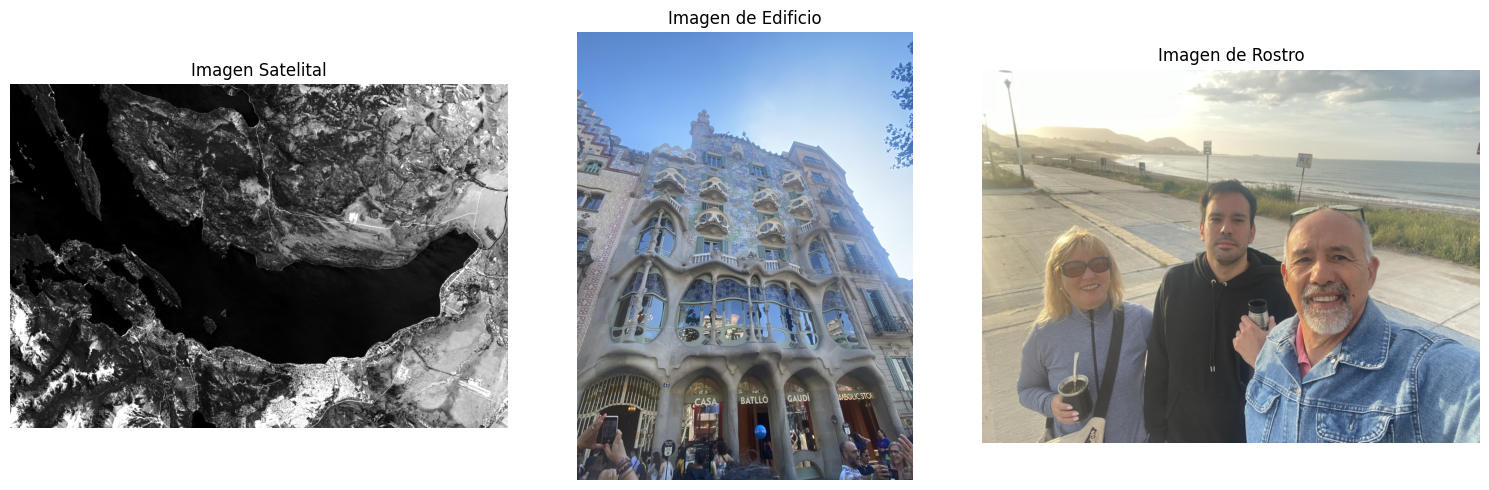

In [14]:
# Leemos las imagenes originales
imagen1 = cv2.imread('imagenesEJ3/bariloche.tif')
imagen2 = cv2.imread('imagenesEJ3/gaudi.jpeg')
imagen3= cv2.imread('imagenesEJ3/perfiles.jpeg')

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Títulos para cada imagen
titulos = ['Imagen Satelital', 'Imagen de Edificio', 'Imagen de Rostro']
imagenes = [imagen1, imagen2, imagen3]

# Mostrar cada imagen en su subplot
for ax, img, titulo in zip(axes, imagenes, titulos):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(titulo)
    ax.axis('off')

plt.tight_layout()
plt.show()


### Analizamos las imagenes

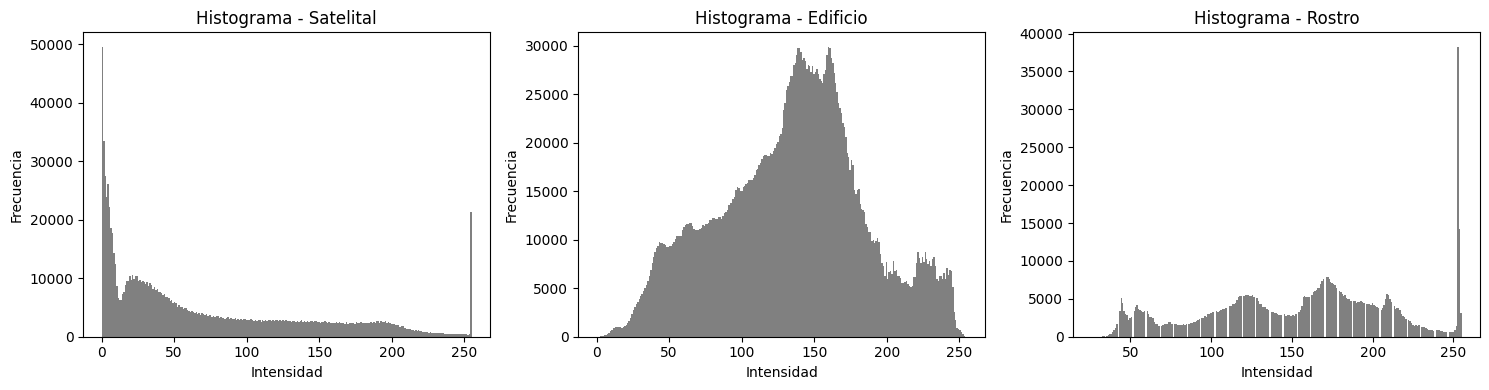

In [16]:
# Mostrar histogramas de las 3 imágenes originales en escala de grises
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
imagenes_grises = [gray1, gray2, gray3]

for ax, img, nombre in zip(axes, imagenes_grises, nombres):
    ax.hist(img.ravel(), bins=256, color='gray')
    ax.set_title(f'Histograma - {nombre}')
    ax.set_xlabel('Intensidad')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


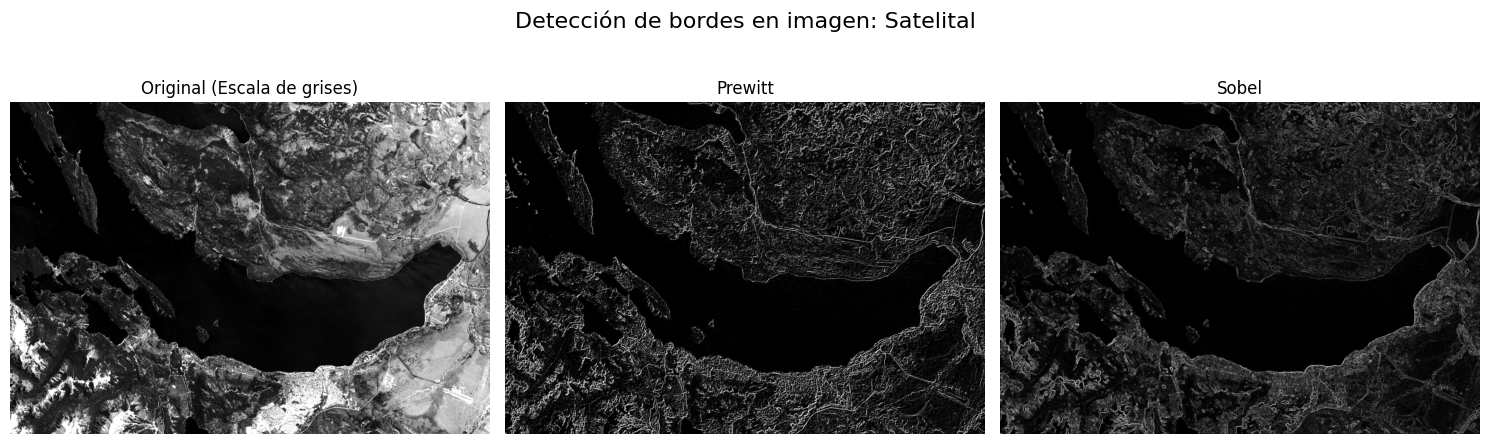

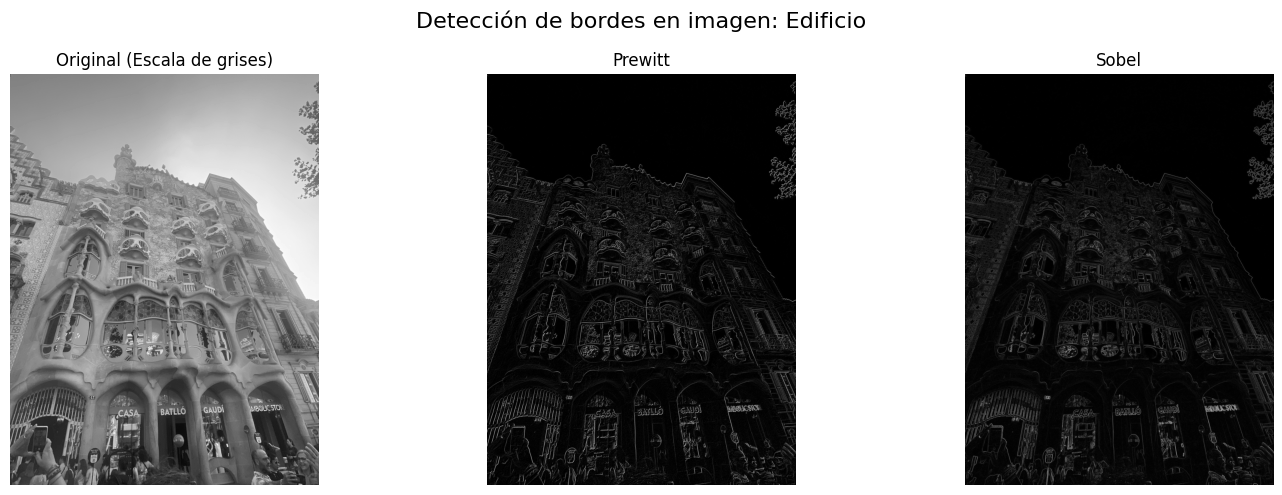

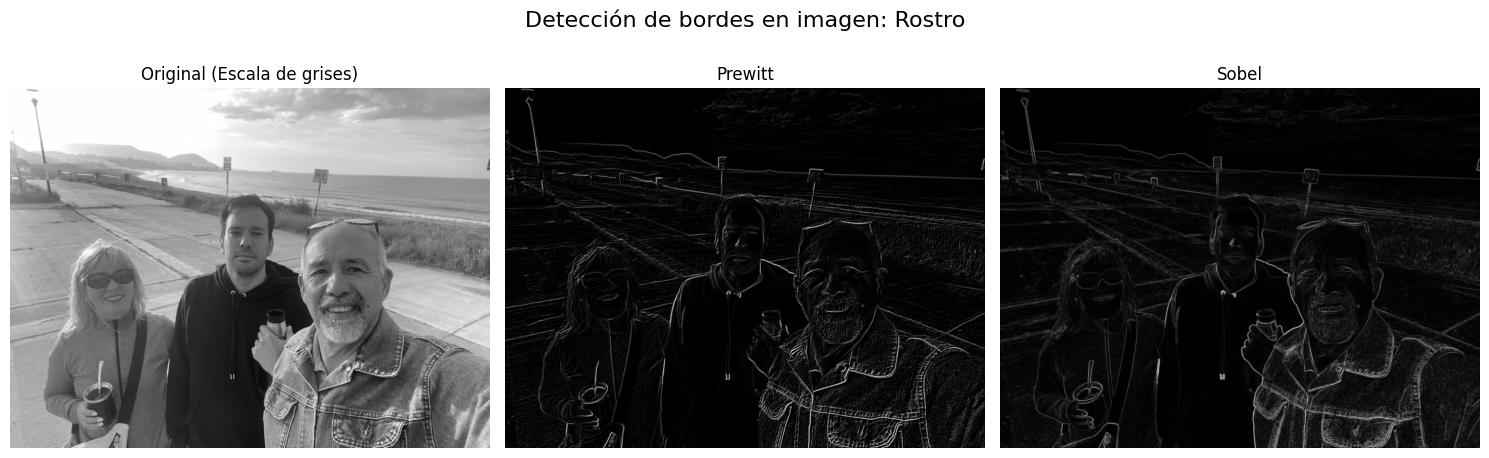

In [15]:
# Convertimos las imágenes originales a escala de grises
gray1 = cv2.cvtColor(imagen1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(imagen2, cv2.COLOR_BGR2GRAY)
gray3 = cv2.cvtColor(imagen3, cv2.COLOR_BGR2GRAY)

# Funciones para aplicar Prewitt y Sobel
def aplicar_prewitt(img):
    kernel_x = np.array([[1, 0, -1],
                         [1, 0, -1],
                         [1, 0, -1]])
    kernel_y = np.array([[1, 1, 1],
                         [0, 0, 0],
                         [-1, -1, -1]])
    gx = cv2.filter2D(img, -1, kernel_x)
    gy = cv2.filter2D(img, -1, kernel_y)
    return np.hypot(gx, gy)

def aplicar_sobel(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.hypot(gx, gy)

# Aplicar filtros
imagenes_grises = [gray1, gray2, gray3]
nombres = ['Satelital', 'Edificio', 'Rostro']

for i, (img_gray, nombre) in enumerate(zip(imagenes_grises, nombres)):
    prewitt = aplicar_prewitt(img_gray)
    sobel = aplicar_sobel(img_gray)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Detección de bordes en imagen: {nombre}', fontsize=16)

    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('Original (Escala de grises)')
    axes[0].axis('off')

    axes[1].imshow(prewitt, cmap='gray')
    axes[1].set_title('Prewitt')
    axes[1].axis('off')

    axes[2].imshow(sobel, cmap='gray')
    axes[2].set_title('Sobel')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


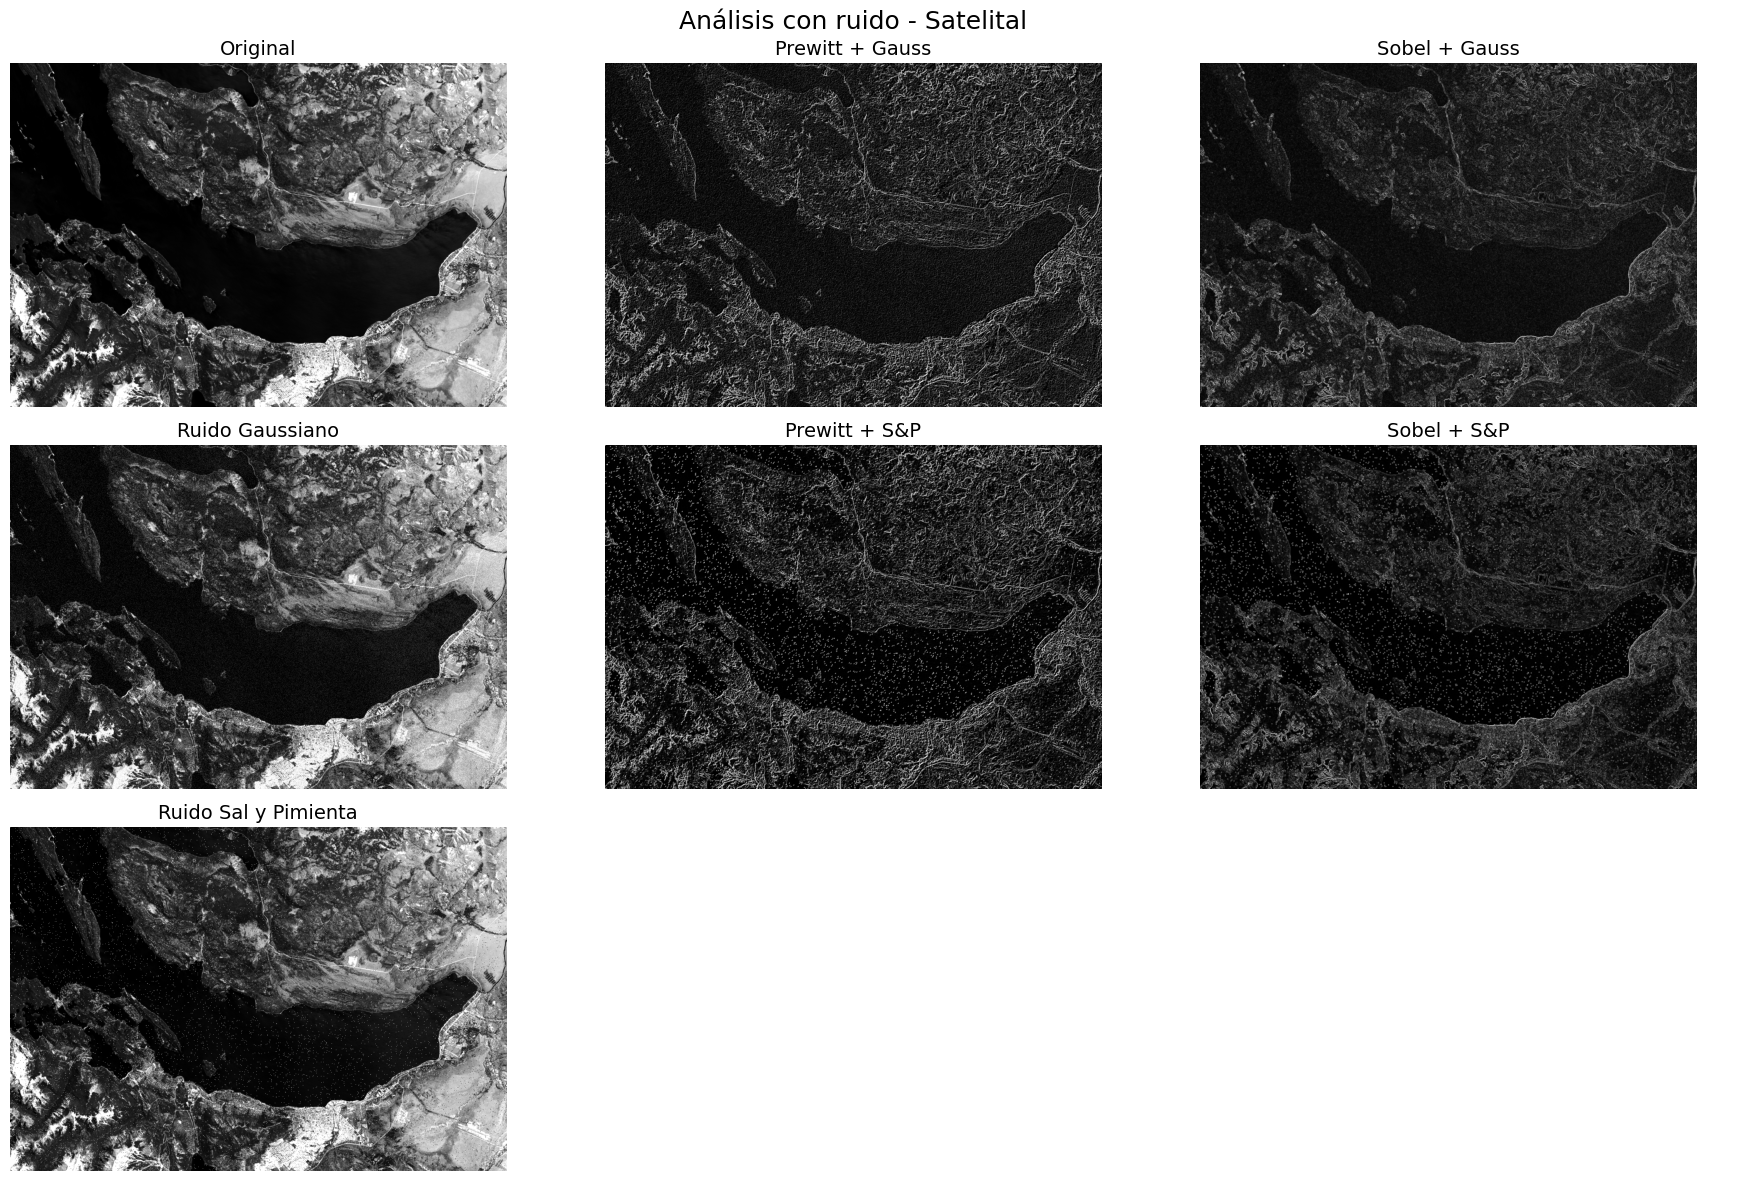

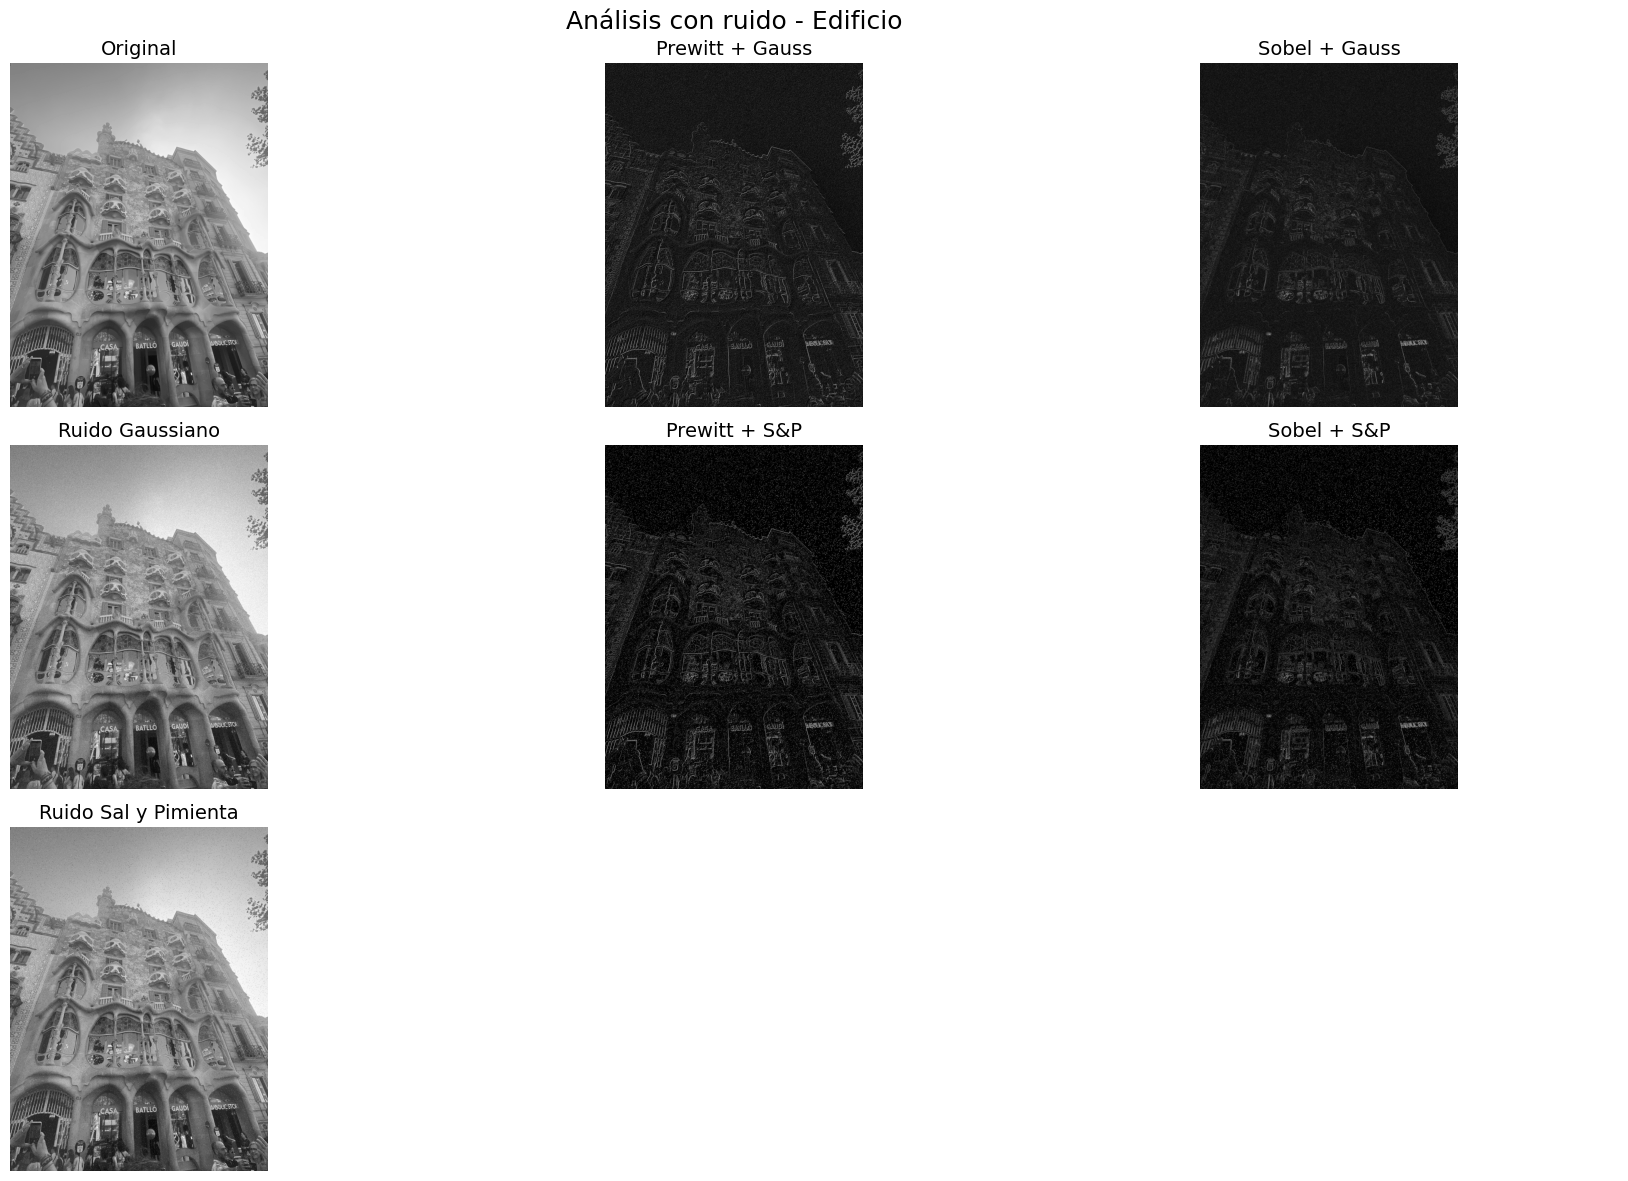

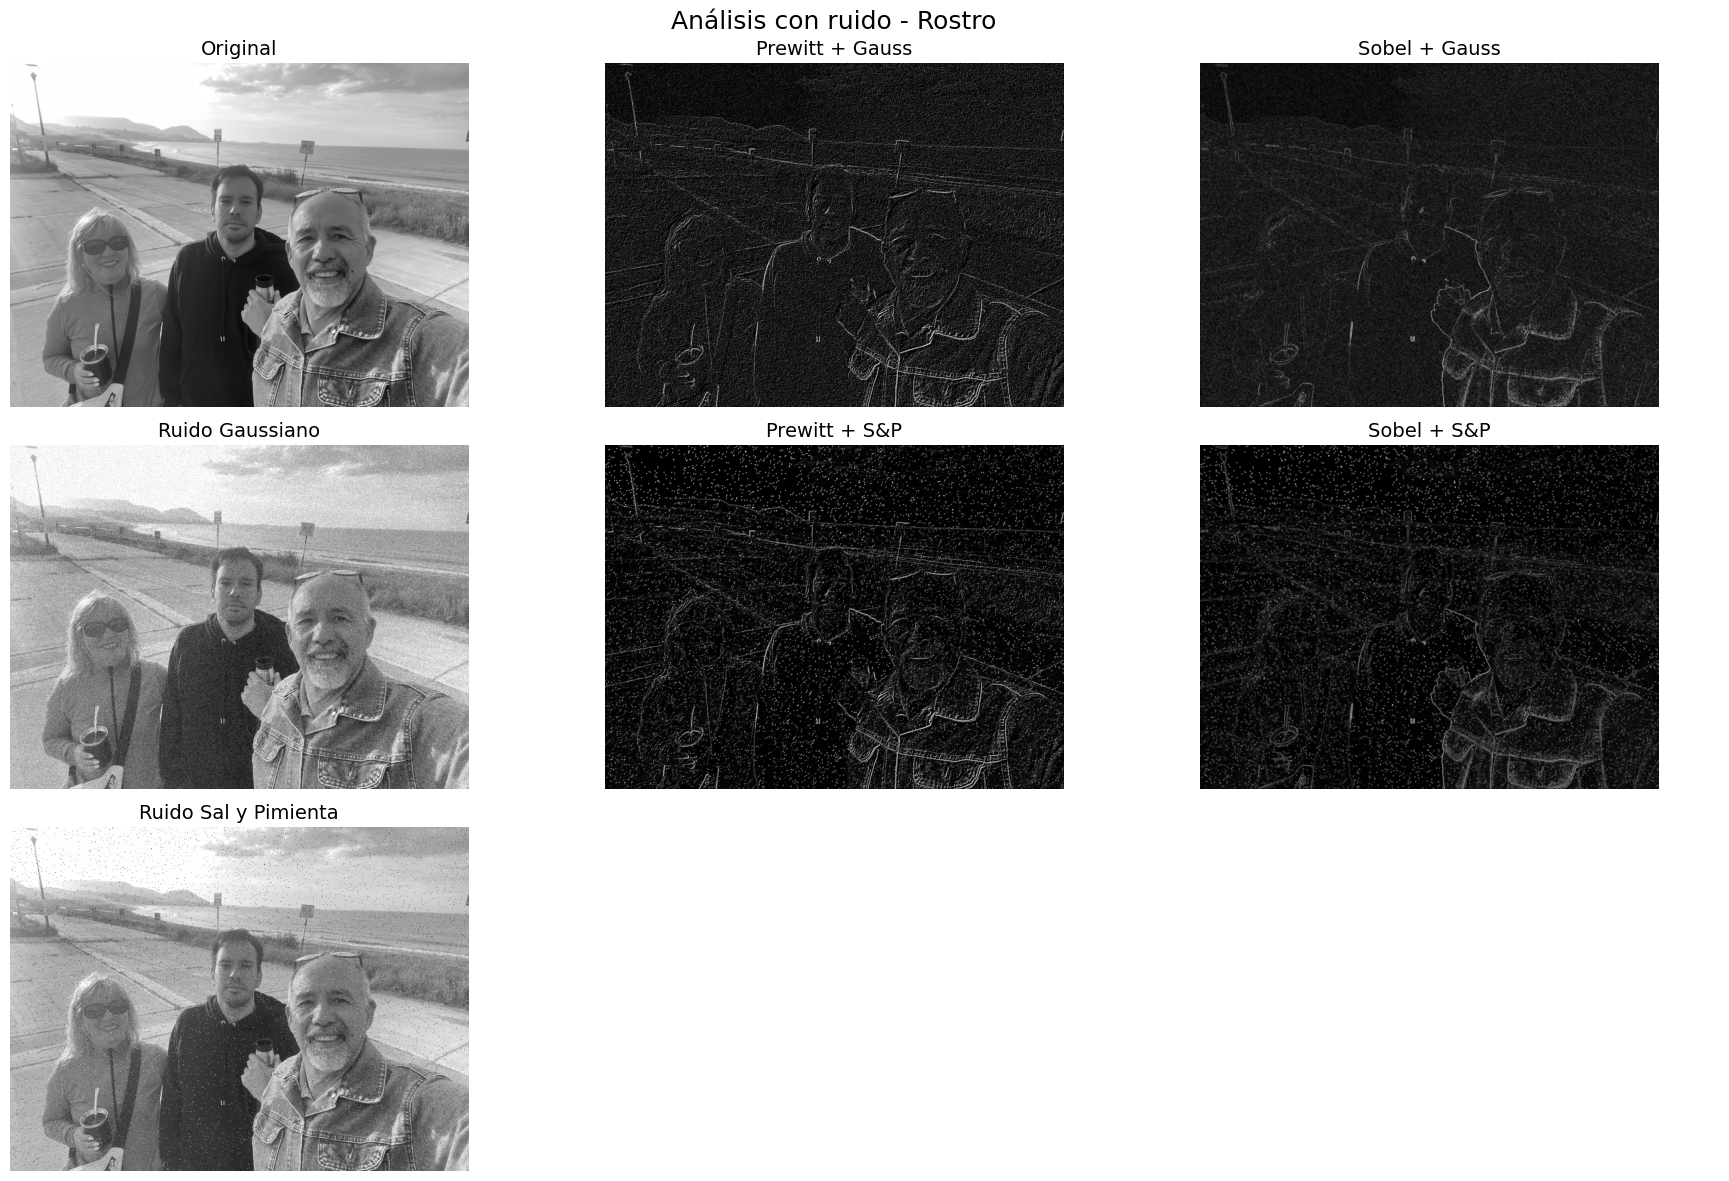

In [ ]:
# Funciones para agregar ruido

def agregar_ruido_sal_pimienta(img, cantidad=0.02):
    img_ruido = img.copy()
    num_salt = np.ceil(cantidad * img.size * 0.5).astype(int)
    num_pepper = np.ceil(cantidad * img.size * 0.5).astype(int)

    # Salt (blancos)
    coords = [np.random.randint(0, i - 1, num_salt) for i in img.shape]
    img_ruido[tuple(coords)] = 255

    # Pepper (negros)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in img.shape]
    img_ruido[tuple(coords)] = 0

    return img_ruido

def agregar_ruido_gaussiano(img, mean=0, std=20):
    gauss = np.random.normal(mean, std, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Funciones de detección de bordes
def aplicar_prewitt(img):
    kernel_x = np.array([[1, 0, -1],
                         [1, 0, -1],
                         [1, 0, -1]])
    kernel_y = np.array([[1, 1, 1],
                         [0, 0, 0],
                         [-1, -1, -1]])
    gx = cv2.filter2D(img, -1, kernel_x)
    gy = cv2.filter2D(img, -1, kernel_y)
    return np.hypot(gx, gy)

def aplicar_sobel(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.hypot(gx, gy)

# Lista de imágenes grises y sus nombres
imagenes = [gray1, gray2, gray3]
nombres = ['Satelital', 'Edificio', 'Rostro']

# Procesar cada imagen
for img, nombre in zip(imagenes, nombres):
    sal_pimienta = agregar_ruido_sal_pimienta(img, 0.02)
    gaussiano = agregar_ruido_gaussiano(img, std=20)

    prewitt_sp = aplicar_prewitt(sal_pimienta)
    sobel_sp = aplicar_sobel(sal_pimienta)

    prewitt_gauss = aplicar_prewitt(gaussiano)
    sobel_gauss = aplicar_sobel(gaussiano)

    # Mostrar resultados con imágenes más grandes
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    fig.suptitle(f'Análisis con ruido - {nombre}', fontsize=18)

    axes[0, 0].imshow(img, cmap='gray')
    axes[0, 0].set_title("Original", fontsize=14)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(prewitt_gauss, cmap='gray')
    axes[0, 1].set_title("Prewitt + Gauss", fontsize=14)
    axes[0, 1].axis('off')

    axes[0, 2].imshow(sobel_gauss, cmap='gray')
    axes[0, 2].set_title("Sobel + Gauss", fontsize=14)
    axes[0, 2].axis('off')

    axes[1, 0].imshow(gaussiano, cmap='gray')
    axes[1, 0].set_title("Ruido Gaussiano", fontsize=14)
    axes[1, 0].axis('off')

    axes[1, 1].imshow(prewitt_sp, cmap='gray')
    axes[1, 1].set_title("Prewitt + S&P", fontsize=14)
    axes[1, 1].axis('off')

    axes[1, 2].imshow(sobel_sp, cmap='gray')
    axes[1, 2].set_title("Sobel + S&P", fontsize=14)
    axes[1, 2].axis('off')

    axes[2, 0].imshow(sal_pimienta, cmap='gray')
    axes[2, 0].set_title("Ruido Sal y Pimienta", fontsize=14)
    axes[2, 0].axis('off')

    for ax in axes[2, 1:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


<hr>
<p style="text-align: center;">
Nombre: <strong>Sosa Suarez Santiago</strong><br>
Materia: <em>Análisis y Tratamiento de Imágenes Satelitales</em><br>
Maestría en Ciencia de Datos – <em>ITBA</em><br>
Fecha: 05 de Julio de 2025
</p>
<hr>